# Milestone 4 – Baseline Model (Linear Regression)

**Project:** Smart Energy Consumption Analysis and Prediction using Machine Learning  
**Intern:** Kunal Bhardwaj  
**GitHub Branch:** kunal_branch  

## Objective
To build a baseline Linear Regression model on the feature-engineered dataset
and evaluate its performance using standard regression metrics.

This baseline will serve as a comparison point for advanced models
(LSTM, deep learning) in later milestones.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


## 1. Load Feature-Engineered Dataset

The dataset is reconstructed using the same preprocessing
and feature engineering steps from Milestone 3 to ensure
reproducibility and consistency.


In [3]:
import pandas as pd
import numpy as np

# Load raw dataset
df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

# Combine Date and Time
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df.set_index("Datetime", inplace=True)

# Select required column
df = df[["Global_active_power"]].dropna()

# Feature engineering (same as Milestone 3)
df["hour"] = df.index.hour
df["weekday"] = df.index.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
df["month"] = df.index.month
df["rolling_mean_24h"] = df["Global_active_power"].rolling(24).mean()

df = df.dropna()

df.head()


,Global_active_power,hour,weekday,is_weekend,month,rolling_mean_24h
Datetime,,,,,,
2006-12-16 17:47:00,5.174,17,5,1,12,4.564167
2006-12-16 17:48:00,4.474,17,5,1,12,4.574917
2006-12-16 17:49:00,3.248,17,5,1,12,4.486917
2006-12-16 17:50:00,3.236,17,5,1,12,4.397833
2006-12-16 17:51:00,3.228,17,5,1,12,4.307833


In [4]:
features = ['hour', 'weekday', 'is_weekend', 'month', 'rolling_mean_24h']
target = 'Global_active_power'

df_model = df[features + [target]].dropna()

split_index = int(len(df_model) * 0.8)

X = df_model[features]
y = df_model[target]

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train.shape, X_test.shape


((1639405, 5), (409852, 5))

## 2. Feature Scaling

Linear Regression is sensitive to feature scale.
Standardization ensures all features contribute equally.


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Linear Regression Model

A Linear Regression model is trained to establish
a simple and interpretable baseline.


In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Model Predictions


In [7]:
y_pred = lr_model.predict(X_test_scaled)


## 5. Model Evaluation

The model is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score


In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

metrics_df


,Metric,Value
0,MAE,0.266948
1,RMSE,0.474975
2,R²,0.718998


## 6. Actual vs Predicted Energy Consumption

This plot compares actual and predicted energy consumption
to visually assess model performance.


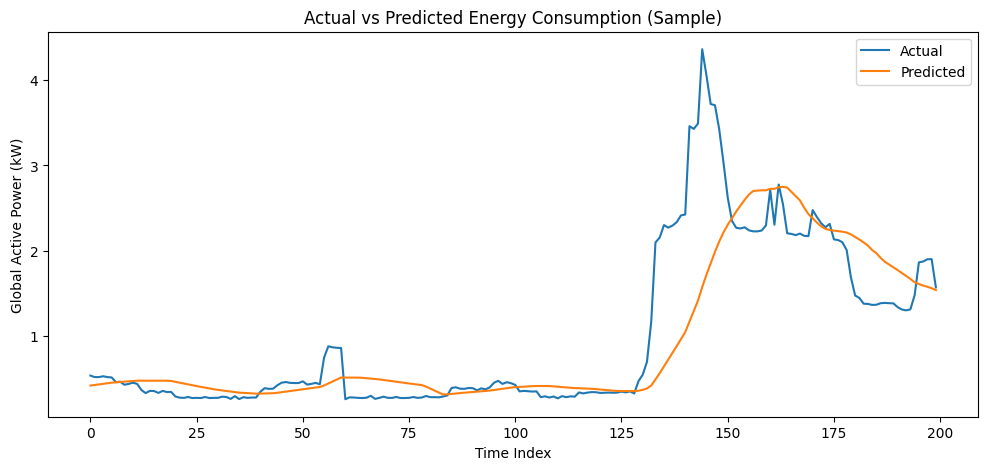

In [10]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Energy Consumption (Sample)")
plt.xlabel("Time Index")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


## 7. Interpretation & Summary

- The Linear Regression model captures the general trend
  of energy consumption.
- Errors indicate that relationships are not purely linear.
- This validates the need for sequence-based models such as LSTM.

### Milestone 4 Summary
- Built a Linear Regression baseline model
- Evaluated performance using MAE, RMSE, and R²
- Visualized actual vs predicted values
- Established a benchmark for advanced models
